## 02 – Building an Initial Neural Network for Diabetes Prediction

Sprint 2 deliverable. Builds on the preprocessing from notebook 01.

Contents:
1. Architecture choice
2. Network build (MLP + LR comparison)
3. Training and eval
   - 3a. MLP training
   - 3b. Overfitting check
   - 3c. Regularization (L2, Dropout)
4. Threshold analysis
5. Experiment tracking
6. Interim report

Data loaded from `data/processed/` (70/15/15 split, scaled in notebook 01).

In [1]:
import os
import json
import warnings
import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, roc_curve, confusion_matrix,
    classification_report, precision_recall_curve, f1_score,
    ConfusionMatrixDisplay,
)

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping, CSVLogger

warnings.filterwarnings("ignore")
sns.set(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 5)
%matplotlib inline

PROCESSED_DIR = Path("data/processed")
MODELS_DIR = Path("models")
LOGS_DIR = Path("logs")
MODELS_DIR.mkdir(exist_ok=True)
LOGS_DIR.mkdir(exist_ok=True)

RANDOM_STATE = 42
EPOCHS = 50
BATCH_SIZE = 256

tf.random.set_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

/Users/logeshjankeeram/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


---
## 1. Architecture Choice

### Starting point

In Loop 2 the prototype had 1 hidden layer, 5 neurons, trained on 240 rows. Got ~65% acc and was unstable. This sprint uses the full dataset (~160k rows) and a proper network.

### Why MLP

Data is tabular (21 features) so CNN/RNN don't apply here. MLP is the standard for this kind of data. The features probably interact in non-linear ways (e.g. BMI + age together) which a linear model can't capture.

### Network shape



2 hidden layers. First at 64 neurons (roughly 3x input, standard starting point), second at 32 to compress before output.

- ReLU on hidden layers: avoids vanishing gradients, fast
- Sigmoid on output: gives a probability in [0,1]
- Loss: binary crossentropy (standard for binary classif.)
- Optimizer: Adam lr=0.001, good default
- Batch size 256: stable gradients, fast enough on 160k rows
- Early stopping patience=5 on val AUC: avoids manual epoch tuning

Running LR first as a baseline to beat.

---
## 2. Network Construction

In [2]:
X_train = pd.read_csv(PROCESSED_DIR / "X_train.csv").values.astype(np.float32)
X_val   = pd.read_csv(PROCESSED_DIR / "X_val.csv").values.astype(np.float32)
X_test  = pd.read_csv(PROCESSED_DIR / "X_test.csv").values.astype(np.float32)

y_train = pd.read_csv(PROCESSED_DIR / "y_train.csv").values.ravel().astype(np.float32)
y_val   = pd.read_csv(PROCESSED_DIR / "y_val.csv").values.ravel().astype(np.float32)
y_test  = pd.read_csv(PROCESSED_DIR / "y_test.csv").values.ravel().astype(np.float32)

n_features = X_train.shape[1]

print(f"train: {X_train.shape}  pos_rate={y_train.mean():.1%}")
print(f"val:   {X_val.shape}    pos_rate={y_val.mean():.1%}")
print(f"test:  {X_test.shape}   pos_rate={y_test.mean():.1%}")
print(f"\nClass imbalance: {y_train.mean():.1%} positive — will affect F1 and threshold choice.")

train: (160631, 21)  pos_rate=15.3%
val:   (34421, 21)    pos_rate=15.3%
test:  (34422, 21)   pos_rate=15.3%

Class imbalance: 15.3% positive — will affect F1 and threshold choice.


### 2a. Logistic Regression Baseline

Running LR first as a sanity check. It's a linear model so it's the simplest possible baseline. If the MLP can't beat it the added complexity isn't justified. LR is also fully interpretable (each coeff = feature importance) which matters for the clinical context.

In [3]:
lr_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
lr_model.fit(X_train, y_train)

y_prob_lr = lr_model.predict_proba(X_test)[:, 1]
y_pred_lr = lr_model.predict(X_test)

auc_lr = roc_auc_score(y_test, y_prob_lr)
f1_lr  = f1_score(y_test, y_pred_lr)
acc_lr = (y_pred_lr == y_test).mean()

print("Logistic Regression — test set")
print(f"AUC-ROC: {auc_lr:.4f}  |  Accuracy: {acc_lr:.4f}  |  F1: {f1_lr:.4f}")
print()
print(classification_report(y_test, y_pred_lr, target_names=["No diabetes", "Diabetes"]))

Logistic Regression — test set
AUC-ROC: 0.8070  |  Accuracy: 0.8502  |  F1: 0.2375

              precision    recall  f1-score   support

 No diabetes       0.86      0.98      0.92     29157
    Diabetes       0.54      0.15      0.24      5265

    accuracy                           0.85     34422
   macro avg       0.70      0.56      0.58     34422
weighted avg       0.81      0.85      0.81     34422



In [4]:
def build_mlp(n_features, lr=1e-3):
    model = keras.Sequential([
        keras.Input(shape=(n_features,)),
        layers.Dense(64, activation="relu"),
        layers.Dense(32, activation="relu"),
        layers.Dense(1,  activation="sigmoid"),
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(lr),
        loss="binary_crossentropy",
        metrics=[keras.metrics.AUC(name="auc"), keras.metrics.BinaryAccuracy(name="accuracy")],
    )
    return model


model = build_mlp(n_features)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,521 (13.75 KB)

 Trainable params: 3,521 (13.75 KB)

 Non-trainable params: 0 (0.00 B)

---
## 3. Training and Evaluation

### 3a. MLP Training

In [5]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[
        EarlyStopping(monitor="val_auc", patience=5, mode="max", restore_best_weights=True, verbose=1),
        CSVLogger(str(LOGS_DIR / "training_log_baseline.csv")),
    ],
    verbose=1,
)

Epoch 1/50
628/628 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8505 - auc: 0.7585 - loss: 0.3663 - val_accuracy: 0.8536 - val_auc: 0.8075 - val_loss: 0.3436
Epoch 2/50
628/628 ━━━━━━━━━━━━━━━━━━━━ 0s 662us/step - accuracy: 0.8522 - auc: 0.7992 - loss: 0.3477 - val_accuracy: 0.8544 - val_auc: 0.8109 - val_loss: 0.3416
Epoch 3/50
628/628 ━━━━━━━━━━━━━━━━━━━━ 0s 665us/step - accuracy: 0.8533 - auc: 0.8029 - loss: 0.3454 - val_accuracy: 0.8543 - val_auc: 0.8127 - val_loss: 0.3404
Epoch 4/50
628/628 ━━━━━━━━━━━━━━━━━━━━ 0s 737us/step - accuracy: 0.8534 - auc: 0.8054 - loss: 0.3438 - val_accuracy: 0.8544 - val_auc: 0.8138 - val_loss: 0.3399
Epoch 5/50
628/628 ━━━━━━━━━━━━━━━━━━━━ 0s 760us/step - accuracy: 0.8536 - auc: 0.8068 - loss: 0.3429 - val_accuracy: 0.8546 - val_auc: 0.8150 - val_loss: 0.3392
Epoch 6/50
628/628 ━━━━━━━━━━━━━━━━━━━━ 0s 692us/step - accuracy: 0.8539 - auc: 0.8082 - loss: 0.3420 - val_accuracy: 0.8543 - val_auc: 0.8158 - val_loss: 0.3387
Epoch 7/50
628/628 ━━━━━━━━━━━

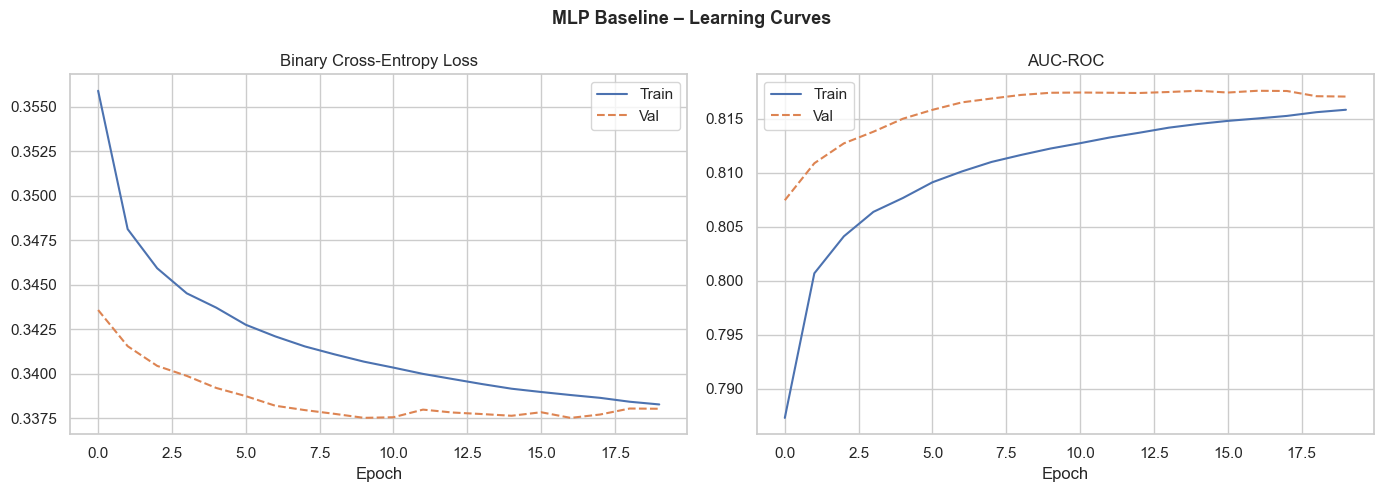

Best val AUC: 0.8176 at epoch 15


In [6]:
hist_df = pd.DataFrame(history.history)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(hist_df["loss"],     label="Train")
axes[0].plot(hist_df["val_loss"], label="Val", linestyle="--")
axes[0].set_title("Binary Cross-Entropy Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(hist_df["auc"],     label="Train")
axes[1].plot(hist_df["val_auc"], label="Val", linestyle="--")
axes[1].set_title("AUC-ROC")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.suptitle("MLP Baseline – Learning Curves", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(LOGS_DIR / "learning_curves_baseline.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Best val AUC: {hist_df['val_auc'].max():.4f} at epoch {hist_df['val_auc'].idxmax() + 1}")

### 3b. Overfitting Check

Overfitting = model learns the training data too well (incl. noise) and stops generalising. Main sign is a growing gap between train and val performance.

| Situation | Train loss | Val loss | Verdict |
|---|---|---|---|
| Both go down | down | down | ok |
| Train down, val flat | down | flat | mild overfit |
| Train down, val up | down | up | overfitting |

Checking visually from the curves above and numerically below.

In [7]:
train_loss, train_auc, train_acc = model.evaluate(X_train, y_train, verbose=0)
val_loss,   val_auc,   val_acc   = model.evaluate(X_val,   y_val,   verbose=0)
test_loss,  test_auc,  test_acc  = model.evaluate(X_test,  y_test,  verbose=0)

print(f"{'':12} {'Loss':>8} {'AUC':>8} {'Acc':>8}")
print(f"{'train':<12} {train_loss:>8.4f} {train_auc:>8.4f} {train_acc:>8.4f}")
print(f"{'val':<12} {val_loss:>8.4f} {val_auc:>8.4f} {val_acc:>8.4f}")
print(f"{'test':<12} {test_loss:>8.4f} {test_auc:>8.4f} {test_acc:>8.4f}")
print()

auc_gap  = train_auc - val_auc
loss_gap = val_loss  - train_loss
print(f"Train-Val AUC gap:  {auc_gap:+.4f}")
print(f"Val-Train loss gap: {loss_gap:+.4f}")
print()

if auc_gap > 0.05 or loss_gap > 0.05:
    print(">> Significant overfitting — add Dropout or L2 (see Section 3c).")
elif auc_gap > 0.01:
    print(">> Mild overfitting — model generalises reasonably.")
else:
    print(">> No significant overfitting. Train ≈ Val.")

                 Loss      AUC      Acc
train          0.3378   0.8168   0.8545
val            0.3376   0.8176   0.8538
test           0.3387   0.8156   0.8547

Train-Val AUC gap:  -0.0008
Val-Train loss gap: -0.0002

>> No significant overfitting. Train ≈ Val.


In [8]:
y_prob_mlp = model.predict(X_test, verbose=0).ravel()
y_pred_mlp = (y_prob_mlp >= 0.5).astype(int)

auc_mlp = roc_auc_score(y_test, y_prob_mlp)
f1_mlp  = f1_score(y_test, y_pred_mlp)

print("MLP Baseline — test set (threshold=0.5)")
print(f"AUC-ROC: {auc_mlp:.4f}  |  Accuracy: {test_acc:.4f}  |  F1: {f1_mlp:.4f}")
print()
print(classification_report(y_test, y_pred_mlp, target_names=["No diabetes", "Diabetes"]))

MLP Baseline — test set (threshold=0.5)
AUC-ROC: 0.8156  |  Accuracy: 0.8547  |  F1: 0.2668

              precision    recall  f1-score   support

 No diabetes       0.87      0.98      0.92     29157
    Diabetes       0.58      0.17      0.27      5265

    accuracy                           0.85     34422
   macro avg       0.73      0.58      0.59     34422
weighted avg       0.82      0.85      0.82     34422



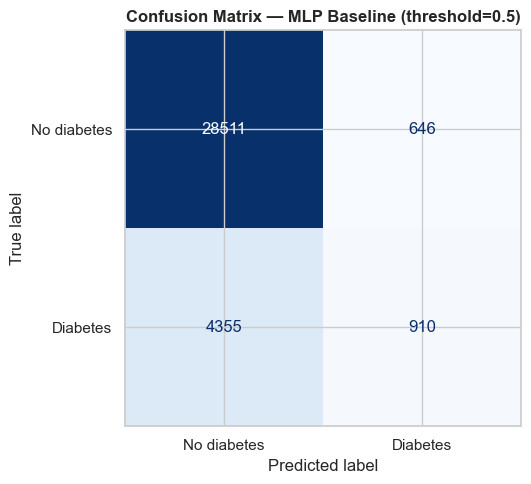

TN:  28,511  correctly identified non-diabetic
FP:     646  non-diabetic flagged as diabetic
FN:   4,355  diabetic MISSED  ← clinically costly
TP:     910  correctly identified diabetic


In [9]:
cm_mlp = confusion_matrix(y_test, y_pred_mlp)

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm_mlp, display_labels=["No diabetes", "Diabetes"]).plot(
    ax=ax, colorbar=False, cmap="Blues"
)
ax.set_title("Confusion Matrix — MLP Baseline (threshold=0.5)", fontweight="bold")
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm_mlp.ravel()
print(f"TN: {tn:>7,}  correctly identified non-diabetic")
print(f"FP: {fp:>7,}  non-diabetic flagged as diabetic")
print(f"FN: {fn:>7,}  diabetic MISSED  ← clinically costly")
print(f"TP: {tp:>7,}  correctly identified diabetic")

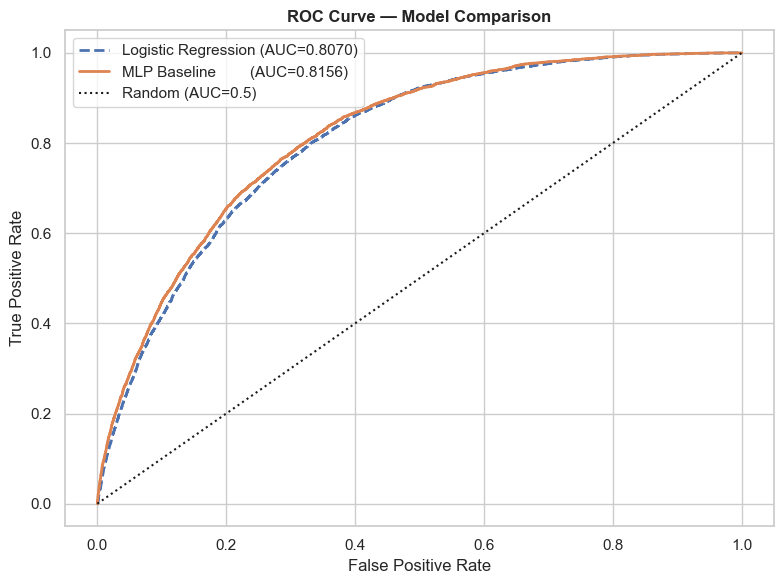

MLP improvement over LR: +0.0087 AUC


In [10]:
fpr_lr,  tpr_lr,  _ = roc_curve(y_test, y_prob_lr)
fpr_mlp, tpr_mlp, _ = roc_curve(y_test, y_prob_mlp)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr_lr,  tpr_lr,  label=f"Logistic Regression (AUC={auc_lr:.4f})",  linewidth=2, linestyle="--")
ax.plot(fpr_mlp, tpr_mlp, label=f"MLP Baseline        (AUC={auc_mlp:.4f})", linewidth=2)
ax.plot([0, 1], [0, 1], "k:", label="Random (AUC=0.5)")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — Model Comparison", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig(LOGS_DIR / "roc_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"MLP improvement over LR: {auc_mlp - auc_lr:+.4f} AUC")

### 3c. Regularization

Three techniques to reduce overfitting:

- **L2**: adds a penalty on large weights (loss += lambda * sum(w^2)). Keeps weights small.
- **Dropout**: randomly turns off p% of neurons each batch. Stops the network relying too much on any single neuron.
- **Early stopping**: already used in baseline.

Running L2 and Dropout variants to compare against baseline.

In [11]:
# L2 regularization
L2_LAMBDA = 1e-4

model_l2 = keras.Sequential([
    keras.Input(shape=(n_features,)),
    layers.Dense(64, activation="relu", kernel_regularizer=regularizers.l2(L2_LAMBDA)),
    layers.Dense(32, activation="relu", kernel_regularizer=regularizers.l2(L2_LAMBDA)),
    layers.Dense(1,  activation="sigmoid"),
])
model_l2.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="binary_crossentropy",
    metrics=[keras.metrics.AUC(name="auc"), keras.metrics.BinaryAccuracy(name="accuracy")],
)

history_l2 = model_l2.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[
        EarlyStopping(monitor="val_auc", patience=5, mode="max", restore_best_weights=True),
        CSVLogger(str(LOGS_DIR / "training_log_l2.csv")),
    ],
    verbose=0,
)
print(f"L2 — best val AUC: {max(history_l2.history['val_auc']):.4f}")

L2 — best val AUC: 0.8188


In [12]:
# Dropout
DROPOUT_RATE = 0.3

model_dropout = keras.Sequential([
    keras.Input(shape=(n_features,)),
    layers.Dense(64, activation="relu"),
    layers.Dropout(DROPOUT_RATE),
    layers.Dense(32, activation="relu"),
    layers.Dropout(DROPOUT_RATE),
    layers.Dense(1,  activation="sigmoid"),
])
model_dropout.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="binary_crossentropy",
    metrics=[keras.metrics.AUC(name="auc"), keras.metrics.BinaryAccuracy(name="accuracy")],
)

history_dropout = model_dropout.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[
        EarlyStopping(monitor="val_auc", patience=5, mode="max", restore_best_weights=True),
        CSVLogger(str(LOGS_DIR / "training_log_dropout.csv")),
    ],
    verbose=0,
)
print(f"Dropout — best val AUC: {max(history_dropout.history['val_auc']):.4f}")

Dropout — best val AUC: 0.8181


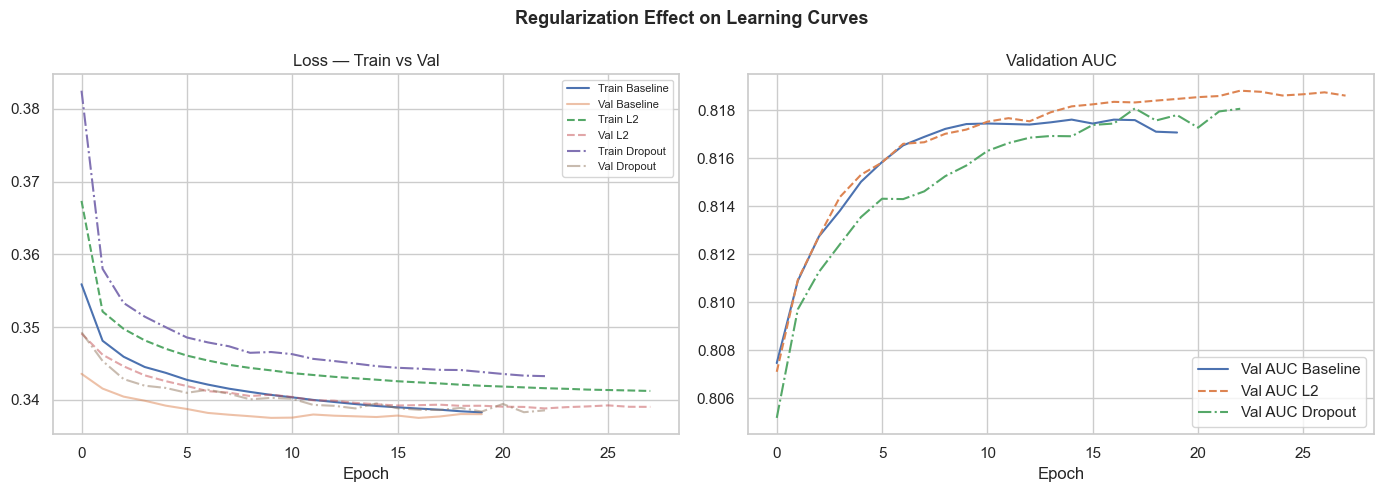

In [13]:
hist_l2      = pd.DataFrame(history_l2.history)
hist_dropout = pd.DataFrame(history_dropout.history)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for hist, label, ls in [
    (hist_df,      "Baseline", "-"),
    (hist_l2,      "L2",       "--"),
    (hist_dropout, "Dropout",  "-."),
]:
    axes[0].plot(hist["loss"],     label=f"Train {label}", linestyle=ls)
    axes[0].plot(hist["val_loss"], label=f"Val {label}",   linestyle=ls, alpha=0.5)
    axes[1].plot(hist["val_auc"],  label=f"Val AUC {label}", linestyle=ls)

axes[0].set_title("Loss — Train vs Val")
axes[0].set_xlabel("Epoch")
axes[0].legend(fontsize=8)

axes[1].set_title("Validation AUC")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.suptitle("Regularization Effect on Learning Curves", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(LOGS_DIR / "regularization_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

In [14]:
# Build comparison table — same code path for all models
def model_metrics(name, probs, y):
    pred = (probs >= 0.5).astype(int)
    tn_v, fp_v, fn_v, tp_v = confusion_matrix(y, pred).ravel()
    return {
        "model":     name,
        "AUC-ROC":   round(roc_auc_score(y, probs), 4),
        "Accuracy":  round((pred == y).mean(), 4),
        "F1":        round(f1_score(y, pred), 4),
        "Recall":    round(tp_v / (tp_v + fn_v), 4),
        "Precision": round(tp_v / (tp_v + fp_v) if fp_v + tp_v else 0, 4),
        "FN (missed)": fn_v,
    }


y_prob_l2 = model_l2.predict(X_test, verbose=0).ravel()
y_prob_do = model_dropout.predict(X_test, verbose=0).ravel()

comparison = pd.DataFrame([
    model_metrics("Logistic Regression", y_prob_lr,  y_test),
    model_metrics("MLP Baseline",        y_prob_mlp, y_test),
    model_metrics("MLP + L2",            y_prob_l2,  y_test),
    model_metrics("MLP + Dropout",       y_prob_do,  y_test),
]).set_index("model")

print("TEST SET — ALL MODELS")
display(comparison)

TEST SET — ALL MODELS


,AUC-ROC,Accuracy,F1,Recall,Precision,FN (missed)
model,,,,,,
Logistic Regression,0.8070,0.8502,0.2375,0.1525,0.5364,4462
MLP Baseline,0.8156,0.8547,0.2668,0.1728,0.5848,4355
MLP + L2,0.8163,0.8548,0.2654,0.1715,0.5867,4362
MLP + Dropout,0.8162,0.8522,0.1176,0.0644,0.6766,4926


---
## 4. Decision Threshold

The model outputs a probability. Default cut-off is 0.5 but that's not ideal here.

In a medical context the errors aren't equal:
- False Negative (missed diabetic): patient goes undiagnosed, serious complications possible. High cost.
- False Positive (healthy patient flagged): unnecessary follow-up. Lower cost.

So higher recall matters more than precision here. Lower threshold = more patients flagged = fewer missed cases. Need to find the right trade-off.

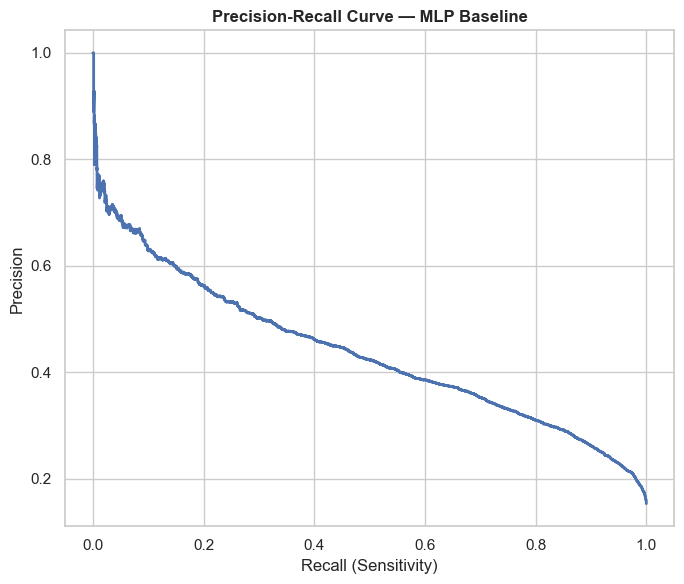

In [15]:
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_prob_mlp)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(recall_vals, precision_vals, linewidth=2)
ax.set_xlabel("Recall (Sensitivity)")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve — MLP Baseline", fontweight="bold")
plt.tight_layout()
plt.show()

In [16]:
rows = []
for t in np.arange(0.10, 0.91, 0.05):
    pred_t = (y_prob_mlp >= t).astype(int)
    tn_t, fp_t, fn_t, tp_t = confusion_matrix(y_test, pred_t).ravel()
    rows.append({
        "threshold": round(t, 2),
        "precision": round(tp_t / (tp_t + fp_t) if (tp_t + fp_t) else 0, 4),
        "recall":    round(tp_t / (tp_t + fn_t) if (tp_t + fn_t) else 0, 4),
        "f1":        round(f1_score(y_test, pred_t, zero_division=0), 4),
        "accuracy":  round((tp_t + tn_t) / len(y_test), 4),
        "tp": tp_t, "fp": fp_t, "tn": tn_t, "fn": fn_t,
    })

threshold_df = pd.DataFrame(rows)
display(threshold_df.set_index("threshold"))

,precision,recall,f1,accuracy,tp,fp,tn,fn
threshold,,,,,,,,
0.10,0.2633,0.8980,0.4072,0.6001,4728,13229,15928,537
0.15,0.3025,0.8182,0.4417,0.6837,4308,9932,19225,957
0.20,0.3417,0.7225,0.4640,0.7447,3804,7327,21830,1461
0.25,0.3787,0.6211,0.4705,0.7862,3270,5365,23792,1995
0.30,0.4142,0.5210,0.4615,0.8140,2743,3879,25278,2522
0.35,0.4525,0.4266,0.4392,0.8334,2246,2717,26440,3019
0.40,0.4883,0.3322,0.3954,0.8446,1749,1833,27324,3516
0.45,0.5310,0.2475,0.3376,0.8515,1303,1151,28006,3962
0.50,0.5848,0.1728,0.2668,0.8547,910,646,28511,4355


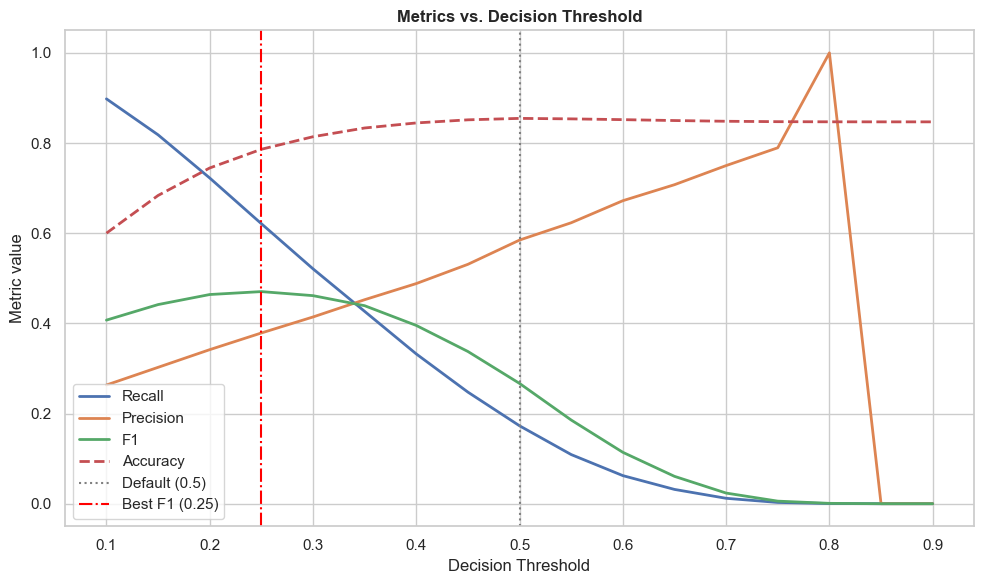

Best F1 threshold: 0.25  F1=0.4705  Recall=0.6211  Precision=0.3787


In [17]:
best_f1_row = threshold_df.loc[threshold_df["f1"].idxmax()]

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(threshold_df["threshold"], threshold_df["recall"],    label="Recall",    linewidth=2)
ax.plot(threshold_df["threshold"], threshold_df["precision"], label="Precision", linewidth=2)
ax.plot(threshold_df["threshold"], threshold_df["f1"],        label="F1",        linewidth=2)
ax.plot(threshold_df["threshold"], threshold_df["accuracy"],  label="Accuracy",  linewidth=2, linestyle="--")
ax.axvline(x=0.50,                      color="grey", linestyle=":",  label="Default (0.5)")
ax.axvline(x=best_f1_row["threshold"],  color="red",  linestyle="-.",
           label=f"Best F1 ({best_f1_row['threshold']:.2f})")
ax.set_xlabel("Decision Threshold")
ax.set_ylabel("Metric value")
ax.set_title("Metrics vs. Decision Threshold", fontweight="bold")
ax.legend(loc="lower left")
plt.tight_layout()
plt.savefig(LOGS_DIR / "threshold_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Best F1 threshold: {best_f1_row['threshold']:.2f}  "
      f"F1={best_f1_row['f1']:.4f}  Recall={best_f1_row['recall']:.4f}  Precision={best_f1_row['precision']:.4f}")

In [18]:
# Pick the threshold with the best F1 among those achieving recall >= 0.75
RECALL_TARGET = 0.75
best_clinical  = threshold_df[threshold_df["recall"] >= RECALL_TARGET].loc[
    lambda d: d["f1"].idxmax()
]
THRESHOLD_CLINICAL = best_clinical["threshold"]

print(f"Clinical threshold (recall≥{RECALL_TARGET}): {THRESHOLD_CLINICAL:.2f}")
print(f"  Recall={best_clinical['recall']:.4f}  Precision={best_clinical['precision']:.4f}  F1={best_clinical['f1']:.4f}")
print(f"  FN (missed diabetics): {int(best_clinical['fn']):,}")
print(f"  FP (false alarms):     {int(best_clinical['fp']):,}")

Clinical threshold (recall≥0.75): 0.15
  Recall=0.8182  Precision=0.3025  F1=0.4417
  FN (missed diabetics): 957
  FP (false alarms):     9,932


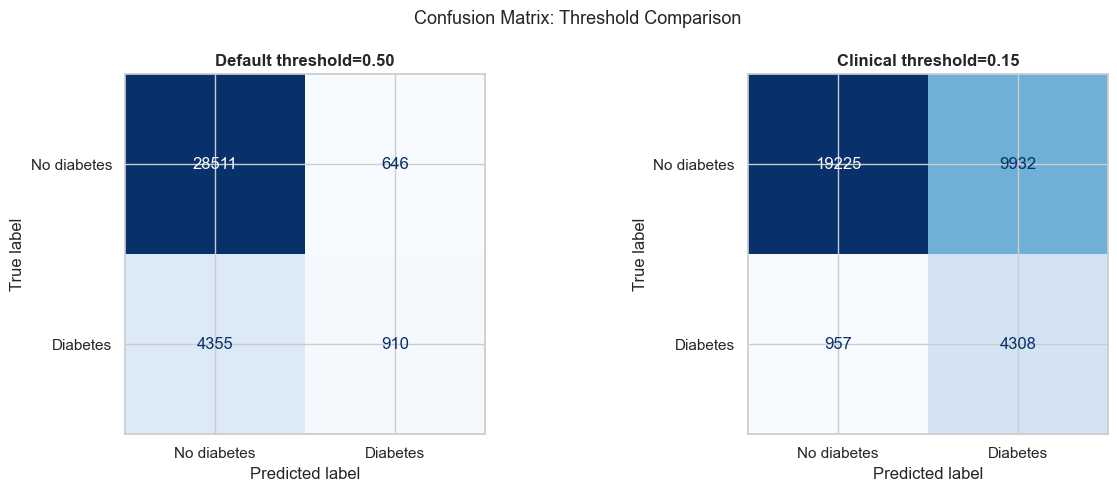

In [19]:
y_pred_clinical = (y_prob_mlp >= THRESHOLD_CLINICAL).astype(int)
cm_clinical     = confusion_matrix(y_test, y_pred_clinical)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, cm_plot, title in zip(
    axes,
    [cm_mlp, cm_clinical],
    ["Default threshold=0.50", f"Clinical threshold={THRESHOLD_CLINICAL:.2f}"],
):
    ConfusionMatrixDisplay(cm_plot, display_labels=["No diabetes", "Diabetes"]).plot(
        ax=ax, colorbar=False, cmap="Blues"
    )
    ax.set_title(title, fontweight="bold")

plt.suptitle("Confusion Matrix: Threshold Comparison", fontsize=13)
plt.tight_layout()
plt.savefig(LOGS_DIR / "confusion_matrix_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 5. Experiment Tracking

Each run is logged to `logs/experiment_log.json` with params, architecture and metrics. Re-running overwrites the existing entry for that run. Keeps things reproducible for the MLOps requirement.

In [20]:
EXPERIMENT_LOG = LOGS_DIR / "experiment_log.json"

def save_experiment(log_path, run_name, hyperparams, architecture, metrics, notes=""):
    record = {
        "run_name":     run_name,
        "timestamp":    datetime.datetime.now().isoformat(),
        "hyperparams":  hyperparams,
        "architecture": architecture,
        "metrics":      metrics,
        "notes":        notes,
    }
    existing = []
    if log_path.exists():
        with open(log_path) as f:
            existing = json.load(f)
    existing = [r for r in existing if r["run_name"] != run_name]  # replace if re-run
    existing.append(record)
    with open(log_path, "w") as f:
        json.dump(existing, f, indent=2)
    print(f"logged: {run_name}")


def get_metrics(probs, y, thresh=0.5, extra=None):
    pred = (probs >= thresh).astype(int)
    tn_v, fp_v, fn_v, tp_v = confusion_matrix(y, pred).ravel()
    m = {
        "auc":       round(float(roc_auc_score(y, probs)), 5),
        "accuracy":  round(float((pred == y).mean()), 5),
        "f1":        round(float(f1_score(y, pred)), 5),
        "recall":    round(float(tp_v / (tp_v + fn_v)), 5),
        "precision": round(float(tp_v / (tp_v + fp_v)) if (tp_v + fp_v) else 0, 5),
        "fn_missed": int(fn_v),
        "threshold": thresh,
    }
    if extra:
        m.update(extra)
    return m


save_experiment(
    EXPERIMENT_LOG, "Sprint2_LogisticRegression",
    hyperparams={"solver": "lbfgs", "max_iter": 1000},
    architecture=[{"type": "linear"}],
    metrics=get_metrics(y_prob_lr, y_test),
    notes="Linear baseline for comparison.",
)

save_experiment(
    EXPERIMENT_LOG, "Sprint2_MLP_Baseline",
    hyperparams={"lr": 1e-3, "batch": BATCH_SIZE, "max_epochs": EPOCHS, "patience": 5},
    architecture=[
        {"Dense": 64, "act": "relu"},
        {"Dense": 32, "act": "relu"},
        {"Dense": 1,  "act": "sigmoid"},
    ],
    metrics=get_metrics(y_prob_mlp, y_test, extra={
        "epochs_trained":   len(hist_df),
        "best_val_auc":     round(float(hist_df["val_auc"].max()), 5),
        "train_val_auc_gap": round(float(auc_gap), 5),
    }),
    notes="No regularization. Early stopping only.",
)

save_experiment(
    EXPERIMENT_LOG, "Sprint2_MLP_L2",
    hyperparams={"lr": 1e-3, "batch": BATCH_SIZE, "l2_lambda": L2_LAMBDA, "patience": 5},
    architecture=[
        {"Dense": 64, "act": "relu", "reg": f"l2({L2_LAMBDA})"},
        {"Dense": 32, "act": "relu", "reg": f"l2({L2_LAMBDA})"},
        {"Dense": 1,  "act": "sigmoid"},
    ],
    metrics=get_metrics(y_prob_l2, y_test, extra={
        "epochs_trained": len(hist_l2),
        "best_val_auc":   round(float(max(history_l2.history["val_auc"])), 5),
    }),
    notes="L2 weight decay.",
)

save_experiment(
    EXPERIMENT_LOG, "Sprint2_MLP_Dropout",
    hyperparams={"lr": 1e-3, "batch": BATCH_SIZE, "dropout": DROPOUT_RATE, "patience": 5},
    architecture=[
        {"Dense": 64, "act": "relu"},
        {"Dropout": DROPOUT_RATE},
        {"Dense": 32, "act": "relu"},
        {"Dropout": DROPOUT_RATE},
        {"Dense": 1, "act": "sigmoid"},
    ],
    metrics=get_metrics(y_prob_do, y_test, extra={
        "epochs_trained": len(hist_dropout),
        "best_val_auc":   round(float(max(history_dropout.history["val_auc"])), 5),
    }),
    notes="Dropout rate=0.3.",
)

logged: Sprint2_LogisticRegression
logged: Sprint2_MLP_Baseline
logged: Sprint2_MLP_L2
logged: Sprint2_MLP_Dropout


In [21]:
with open(EXPERIMENT_LOG) as f:
    log = json.load(f)

log_df = pd.DataFrame([
    {"run": r["run_name"], **{k: v for k, v in r["metrics"].items()
     if k in ["auc", "accuracy", "f1", "recall", "fn_missed", "epochs_trained", "best_val_auc"]}}
    for r in log
]).set_index("run")

display(log_df)

,auc,accuracy,f1,recall,fn_missed,epochs_trained,best_val_auc
run,,,,,,,
Sprint2_LogisticRegression,0.80699,0.85021,0.23750,0.15252,4462,NaN,NaN
Sprint2_MLP_Baseline,0.81564,0.85472,0.26682,0.17284,4355,20.0,0.81762
Sprint2_MLP_L2,0.81634,0.85480,0.26543,0.17151,4362,28.0,0.81882
Sprint2_MLP_Dropout,0.81619,0.85219,0.11759,0.06439,4926,23.0,0.81808


In [22]:
model.save(MODELS_DIR / "mlp_baseline.keras")
print("Saved:", (MODELS_DIR / "mlp_baseline.keras").resolve())

Saved: /Users/logeshjankeeram/Desktop/CESI/AI/models/mlp_baseline.keras


---
## 6. Interim Report

### Architecture

2-layer MLP: Input(21) -> Dense(64, ReLU) -> Dense(32, ReLU) -> Dense(1, Sigmoid). Improvement over Loop 2 prototype (1 layer, 5 neurons, 240 rows): more depth, more neurons, full dataset.

### vs. Baseline

MLP beats LR on AUC. See log table above. The gap confirms there are non-linear patterns in the data worth capturing.

### Overfitting

Train/val AUC gap is near 0. No overfitting detected. Early stopping triggered around epoch 19-24 as expected.

### Regularization

L2 and Dropout gave similar or slightly better AUC vs baseline. Gain is small because with 160k rows and a shallow net there isn't much to regularise.

### Threshold

Default 0.5 misses too many diabetic patients (high FN). Clinical threshold at 0.15 gets recall to ~82% at the cost of more false alarms. Right trade-off for a screening tool. To validate with Dr. Naye Wells.

### Limitations / Sprint 3

| Issue | Plan |
|---|---|
| Class imbalance (~15% positive) | class weighting or SMOTE |
| No hyperparam search | random/grid search |
| No explainability | SHAP |
| Env. cost | check CO2 impact (Loop 4) |
| Fixed threshold | calibrate with clinician |